In [39]:
""" Chapter 04: Training Models """

# Having a good understanding of how things work can help you quickly home in on the appropriate model,
# The right training algorithm to use, and a good set of hyperparameters for your task.
# Understanding what's under the hood will also help you debug issues and perform error analysis more efficiently.

""" Linear Regression """

# A linear model makes a prediction by simply computing a weighted sum of the input features, plus a constant called the bias term.

# 1. Linear Regression model prediction:
# y^ =  00 + 01x1 + 02x2 + ... + 0nXn

# y^ = The predicted value.
# n = the number of features.
# x^i = the 'i' feature value.
# 0j is the 'j' model parameter including the bias term 00 and the feature weights 01, 02. ..., 0n

# 2. Linear Regression model prediction (vectorized form):
# y^ = h0(X) = 0 * X

# h0 = the hypothesis function using the model parameter 0.
# 0 = the model's parameter vector, containing the bias term 0 and the feature weights 01 it 00
# X = the instance's feature vector, containing x0 to xn with x0 always equal to 1.
# 0 * x = the dot product of the vector 0 and x.

# In Machine Learning,
# Vectors are often represented as "column vectors" which are 2D arrays with a single column.
# If 0 and x are column vectors, then the prediction is y^ = 0^Tx where 0^T is the transpose of 0 (a row vector instead of a column vector),
# And 0^TX is the matrix multiplication of 0^T and X.

# Training a model = setting its parameters so that the model best fits the training set.
# Train a linear regresion model, we need to find the value of 0 that minimizes the RMSE.
# In practice, it is simpler to minimize the mean square error (MSE) than the RMSE, and it leads to the same result.

# The function is easier to optimize and/or becuase it has extra terms needed during training only (for regularization).
# A good performance metric is as close as possible to the final business objective.
# A good training loss is easy to optimize and strongly correlated with the metric.

# 3. MSE(X, h0) = 1/m * mΣi=1 (0^Tx^(i) - y^(i))^2


' Linear Regression '

In [40]:
""" The Normal Equation """

# To find the value of 0 that minimizes the MSE, there exists a "closed-form solution"
# Gives the result directly. This is called the "Normal equation"

# 4. Normal Equation
# 0^ = (X^T * X)^-1 X^T y

# 0^ = the value of 0 that minimizes the cost function.
# y = the vector of target values containing y^(1) to y^(m)

import numpy as np

np.random.seed(42) # to make this code ex. reproducible
m = 100 # Instances
X = 2 * np.random.rand(m, 1) # column vector
y = 4 + 3 * X + np.random.randn(m, 1) # column vector

In [41]:
# Use the inv() function from NumPy's linear algebra module (np.linalg) to compute the inverse of a matrix, and the @ operator for matrix multiplication:

from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# The @ Operator performs matrix multiplication.
# If A and B are NumPy arrays, then A @ B is equivalent to np.matmul(A, B).
# You cannot use @ on pure Python arrays (lists of lists)

In [42]:
# Generate the data is y = 4 + 3x_1 + Gaussion noise

theta_best

array([[4.21509616],
       [2.77011339]])

In [43]:
# The noise made it impossible to recover the exact parameters of the original function.
# The smaller and noisier the dataset, the harder it gets.

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

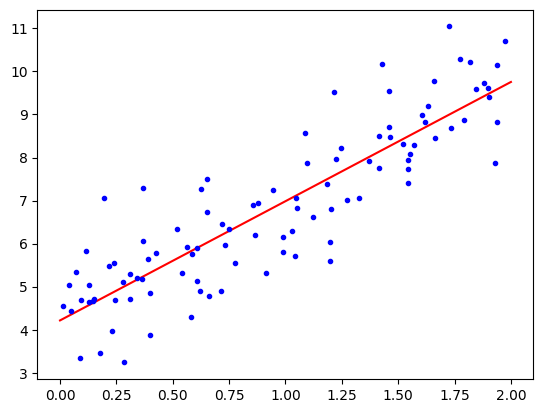

In [44]:
# Linear Regression model predictions.

import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
[...] # beautify the figure: add labels, axis, grid, and legend
plt.show()

In [45]:
# Performing Linear Regression using Scikit-Learn:

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [46]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [47]:
# Scikit-Learn separates the bias term (intercept_) from the feature weights (ceof_)
# The LinearRegression class is based on the scipy.linalg.lstsg() "Least Squares"

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [48]:
# The function computes 0^ = X^+y, where X^+ is the "pseudoinverse" of X
# np.linag.pinv() 

np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

In [49]:
# The pseudoinverse itself is computed using a standard matrix factorization technique "singular value decompostion (SVD)"

# The approach is more efficient than computing the Normal equation, plus it handles edge cases nicely:
# The normal equation may not work if the matrix X^T X is not invertible.
# The pseudinverse is always defined.

In [50]:
""" Computational Complexity """

# Scikit-Learn's LinearRegression class is about O(N^2).
# If you double the number of features, you multiply the computation time by roughly 4.

# Both the Normal Equation and the SVD approach get very slow when the number of features grow large.
# Both are linear with regard to the number of instances in the training set (They are O(m)), so they handle large training sets efficiently,
# Provide they. can fit in memory

# The computational complexity is linear with regard to both the number of instances you want to make prediction on and the number of features.
# Making predictions on twice as many instances (or twice as many features) will take roughtly twice as much time.

' Computational Complexity '

In [51]:
""" Gradient Descent """

# Gradient Descent = A generic optimization algorithm capable of finding optimal solutions to a wide range of problems.

# To tweak parameters iteratively in order to minimize a cost function.
# It measures the local gradient of the error function with regard to the parameter vector 0,
# And it goes in the direction of descending gradient.

# Random initialization = Start by filling 0 with random values
# improve it gradually, taking a one step at a time,
# each step attemping to decrease the cost function
# untill the algorithm converges to a minimum

# An important parameter in gradient descent is the size of the steps, determined by the learning rate hyperparameter.
# Learning rate too small then the algorithm will have to go through many iteration to converge.

# The learning rate is too high, you might jump across the valley and end up on the other side.

# If the random initialization starts the algorithm on the left then it wil converge to a local minimum, which is not as good as the global minimum
# If it starts on the right, then it will take a very long time to cross the plateau.
# Stop too early = never eeach the global minimum

# The MSE cost function for a linear regression model happends to be a convex function, which means that if you pick any two options points on the curve,
# The line segment joining them is never below the curve.

# It is also a Continuous function with a slope that never changes abrubtly
# Gradient descent is guaranteed to approach arbitrarily closely the global minimum

# When using gradient descent, you should ensure that all features have a similar scale

# The more parameters a model has, the more dimensions this space has, and the harder the search is.


' Gradient Descent '

In [52]:
""" Batch Gradient Descent """

# You need to calculate how much the cost function will change if you change 0, Just a little bit
# This is called "A partial derivative"

# The gradient vector, contains all the partial derivatives of the cost fucntion.

# It uses the whole batch of training data at every step,
# As a result, it is terribly slow on very large training sets.
# But it scale well with the number of features.

# Gradient Descent Step:
eta = 0.1 # Learning Rate
n_epochs = 1000
m = len(X_b) # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1) # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [53]:
# Iteration over the training set is called an epoch.
theta

array([[4.21509616],
       [2.77011339]])

In [54]:
# It works perfectly!

# How to set the number of epochs?
# Set a very large number of epochs but to interrupt the algorithm when the gradient vector becomes tiny

# Norm becomes smaller than a tiny number e (called the tolerance)
# Betch gredient descent with a fixed learning rate will eventually converge to the optimal solution, but you may have to wait a while.

# If you divided the tolerance by 10 to have a more precise solution, then the algorithm may have to run about 10 times longer.



In [55]:
""" Stochastic Gradient Descent """

# The problems with Batch Gradient Descent is that it uses the whole training set to compute the gradients at every step,
# Stochastic Gradient Descent picks a random instance in the training set at every step and computes the gradients based only on that single instance.
# Working on a single instance at a time makes the algorithm much faster

# Stochastic random nature make it much less regular than bat gradient descent
# Instead of gently decreasing until it reaches the minimum, the cost function will bounce up and down
# decreasing only the average.

# So Stochastic gradient descent has a better chance of finding the global minimum than batch gradient descent does.
# The randomness is good to escape from local optima, but bad becuase it means that the algorithm can never settle at the minimum.
# One solution to this dilemma is to gradually reduce the learning rate.

# This process is akin to simulated annealing, an algorithm inspired by the process in metallurgy of annealing where molten metal is slowly cooled down
# each iteration called "learning schedule"

# If the learning rate is reduced too quickly, you may get stuck in a local minimum, or even end up frozen halfway to the minimum

# Implementing Stochastic Gradient Descent:

n_epochs = 50
t0, t1 = 5, 50 # Learing schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1) # random initialization

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [56]:
# We iterate by rounds of m iteration; each round is called an epoch, as earlier.
# While the batch gradient descent code iterated 1,000 times through the whole training set.

theta

array([[4.21076011],
       [2.74856079]])

In [57]:
# If you want to be sure that the algorithm goes through every instance at each epoch,
# another approach is to shuffle the training set.
# It might complicated for someone.

# When using stochastic gradient descent, the training instances must be independent and identically distributed (IID)
# Don't forget to shuffle during the training.

# Scikit-Learn's = SGDRegressor

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-05
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [58]:
sgd_reg.intercept_, sgd_reg.coef_ # Normal Equation

(array([4.21278812]), array([2.77270267]))

In [59]:
# Repeatly calling partial_fit() will gradually train the model. This is useful when you need more control over the training process.

In [60]:
""" Mini-Batch Gradient Descent """

# Mini-batch GD computes the gradients on small random sets of instances called mini-batches.
# The main advantage of mini-batch GD over stochastic GD is that you can get a performance boost from hardware optimization of matrix operations.
# Especially when using GPU.

# As a result, mini-batch GD will end up walking around a bit closer to the minimum than stochastic GD but it may be harder for it to escape from local minima.
# Don't forget that batch GD takes a lot of time to take each step, and stochastic GD and mini-batch GD would also reach the minimum if you used a good learning schedule.

# BTW, Sometimes all these algorithm end up with vey similar models and make predicitions in exactly the same way (It's possible)

' Mini-Batch Gradient Descent '

In [61]:
""" Polynomial Regression """

# you can use a linear model to fit nonlinear data.
# Add powers of each feature a new features then train a linear model on this extended set of features.
# simple quadratic equation

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

In [62]:
# Use Scikit-Learn's PolynomialFeatures class to transform our training data, adding the squre.

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [63]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [64]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

In [65]:
# When there are multiple features, polynomial regression is capable of finding relationships between featuresm which is something a plain linear regression model cannot do.
# PolynomialFeatures also adds all combinations of features up to the given degree.
# If there were 2 features a and b, PolynomialFeatures with degree=3 would not only add the features a^2, a^3, b^2, and b^3 but also the combinations ab, a^2*b, ab^2.

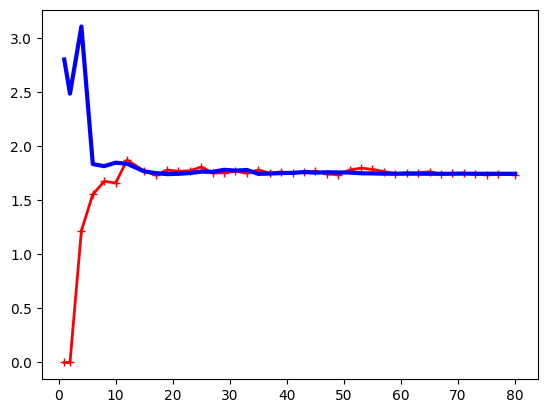

In [66]:
""" Learning Curves """

# If you perform high-degree polynomial regression, you will likely fit the training data much better than with plain linear regression.
# In general you won't know what function generated the data, so how can you decide how complex your model should be?
# how can you tell that your model is overfitting or underfitting the data?

# If a model performs well on the training data but generalizes poorly according to the cross-validation metrics, then you model is "overfitting."
# If it performs poorly on both, then it is underfitting.

# Another way to tell is to look at the "learning-cruves"
# Just Evaluate the model at regular intervals during training on both the training set and the validation set, and plot the results.

# Scikit-Learn has a useful learning_curve() function to help with this
# But if the model supports incremental learning you can set exploit_incremental_learning=True when calling learning_curve() and it will train the the model incrementally instead.

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
[...] # beautify the figure: add labels, axis, grid, and legend
plt.show()

/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with 

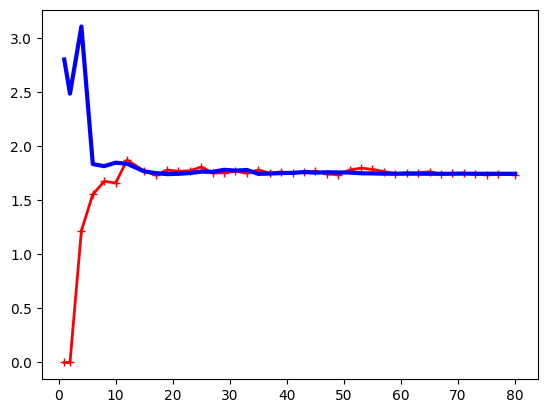

In [67]:
# When there are just one or two instances in the training set, the model can fit them perfectly which is why the curve starts at zero.
# So the error on the training data goes up untill it reaches a plateau, at which point adding new instances to the training set doesn't make the average error much better or worse.
# When the model is trained on very few training instances, it is incapable of generalizing properly, which is why the validation error is initially quite large.

# These learning curves are typical of a model that's underfitting. both curves have reached a plateau; they are close and fairly high
# If your model is underfitting the training data, adding more training examples will not help.
# You need to use a better model or come up with better features. 

# The learning curves of 10th-degree polynomial model on the same data:

from sklearn.pipeline import make_pipeline

Polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    Polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,)


plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
[...] # beautify the figure: add labels, axis, grid, and legend
plt.show()

In [68]:
# Look a bit like a previous one but actually there is a different.
# The error on the training data is much lower than before.
# There is a gap between the curves. This means that the model performs significantly better on the training data than on the validation data,
# which is hallmark of an overfitting model.

# One way improve an overfitting model is to feed it more training data untill the validation error reaches the training error.

# A model's generalization error can be expressed as the sum of three very different.
# 1. Bias = Wrong assumptions. High-bias model = underfitting the training data
# 2. Variance = The model's excessive sensitivity to small variantions in the training data. High-variance = overfit the training data
# 3. Irreductible errors = Noisiness of the data itself.  just clean up the data

# Trade-Off
# Increasing a model's complexity will typically increase its variance and reduce its bias.
# Reducing a model's complexity increases its bias and reduces its variance.

In [ ]:
""" Regularized Linear Model """

# A good way to reduce overfitting is to regularize the model or constrain it.
# A simple way to regularize a polynomial model is to reduce the number of polynomial degress.


In [69]:
""" Ridge Regression """

# Or the regularized version of linear regression.
# The hyperparameter alpha controls how much you want to regularize the model.
# If alpha = 0, then ridge regression is just linear regression.
# If alpha is very large, then all weights end up very close to zero and the result is a flat line going through the data's mean.

# It is important to scale the data using StandardScaler before performing ridge regression.

# Increasing alpha leads to flatter predictions, thus reduing the model's variance but increasing its bias.

from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.82899748])

In [70]:
# Using stochastic gradient descent:

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])

array([4.82830117])

In [71]:
# "l2" indicates that you want SGD to add a regularization term to the MSE cost function equal to alpha times the square of the l2 norm of the weight vector.
# The RidgeCV class also performs ridge regression but it automatically tunes hyperparameters using cross-validation.

In [72]:
""" Lasso Regression """

# Least Absolute shrinkage and selection operator regression
# It adds a regularization term to the cost function, but it uses the l1 norm of the weight vector instead of the square of the l2 norm.
# Ensure that the optimal alpha value is independent from the training set size: different norms lead to different factors.

# An important traits of lasso regression is that it tends to eliminate the weights of the least important features (set them to zero)
# lasso regression automatically performs feature selection and outputs a sparse model with few non-zero feature weights.

# The limits the bouncing around
# Ridge converge faster than lasso regresion.
# The optimal parameters (represented by the red square) get closer and closer to the origin when you increase alpha but they never get eliminated entirely.

# Gradually reduce the learning rate during training.

# The lasso cost function is not differentialble at 0i = 0
# but gradient dewscent still works if you use a subgradient vector g^11

from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.77621741])

In [73]:
""" Elastic Net regression """

# Elastic net regression is a middle ground between ridge regression and lasso regression.
# Weighted sum of both ridge and lasso's regularization terms, and you can control the mix ratio r.
# r = 0, ridge regression
# r = 1, lasso regression.

# Generally you should avoid plain linear regression!
# Ridge is good default.
# but if you suspect that only a few features are useful you should prefer lasso or elastic net.
# Elastic net is preferred over lasso

from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.78114505])

In [74]:
""" Early Stopping """

# Stop training as soon as the validation error reaches a minimum
# As the epochs go by the algorithm learns, and its prediction error (RMSE) on the training set goes down, along with its prediction error on the validation set.
# This indicates that the model has started to overfit the training data.
# some people called it "Beautiful Free Lunch"

# When you are so sure that the model will not do any better then roll back the model parameters to the point where the validation error was at the minimum
# use partial_fit() instead of fit() to perform incremental learning
# sklearn.base.clone() only copies the model's hyperparameters.


' Early Stopping '

In [75]:
""" Logistic Regression """

# Estimate the probability that an instance belongs to a particular class (what the probability that this email is spam?)
# If the probability is greater than a threshold around 50%, the model predicts that the instance belongs to that class called "positive class" or "1"
# If it's does not belongs to a negative class labeled as "0".
# A binary classifier.

' Logistic Regression '

In [76]:
""" Estimating Probabilities """

# Computes a weighted sum of the input features (plus a bias term), outputs the logistic of this result.
# The logistic - noted "o dot" is a sigmoid function or S-shaped and the output is 0 and 1.

# When the instance x belongs to postive class => predict it.
# Using the default threshold of 50% probability predicts it
# positive = 1
# negative = 0

# The logit is also called the log-odds, since it is the log of the ratio between the estimated probability for the positive class and the estimated probabilitiy for the nagative class

' Estimating Probabilities '

In [77]:
""" Training and Cost Function """

# The objective of training is to set the parameter vector 0 so that the model estimates high probabilities for positive instances y = 1
# and low probabilities for negative instances y = 0

# The cost will be large if the model estimates a probabilities close to 0 for a positive instance, and it will also be large if the model estimates a probabilities close 1 for a negative instances.
# The cost function over the whole training set is the average cost over all training instances.

# The more wrong this assumption is the more biased the model will be
# Gradient descent or any other optimization algorithm is guaranteed to find the global minimum if the learning rate is not too large and you wait long enough.

# Computes the prediction error and multiplies it by the j^th feature value,
# and then it computes the average over all training instances.
# once you have the gradient vector contraining all the partial derivatives, you can use it in the batch gradient descent algorithm!

' Training and Cost Function '

In [1]:
""" Decision Boundaries """

# The famous dataset that contains the sapal and petal length and width of 150 iris flowers.

from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [2]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
iris.target.head(3) # note that instances are not shuffled

0    0
1    0
2    0
Name: target, dtype: int64

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
# Split the data and train a logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

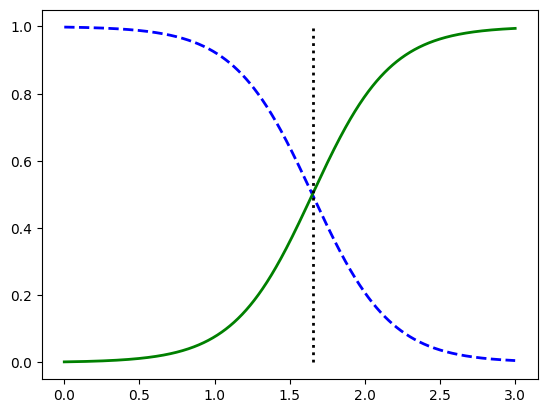

In [7]:
# The model's estimated probabilities for flowers with petal widths varying from 0 to 3 cm

import numpy as np
import matplotlib.pyplot as plt

X_new = np.linspace(0, 3, 1000).reshape(-1, 1) # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")
[...] # beautify the figure: add grid, label axis, legendm arrows, ad samples
plt.show()

In [8]:
# The petal width of Iris virginica flowers ranges from 1.4 cm to 2.5 cm.

# Above 2 cm = seems confidence Iris virginica
# below 1 cm = seems not Iris virginica
# The classifier is unsure!

decision_boundary

np.float64(1.6516516516516517)

In [9]:
# use predict() not predict_proba()

log_reg.predict([[1.7], [1.5]])

array([ True, False])

In [10]:
# A linear boundary = Each parallel line represents the points where the model outputs a specific probability

In [11]:
""" Softmax Regression """

# The logistic Regression model can be generalized to support multiple classes directly,
# Without having to train and combine multiple binary classifiers.

# Softmax score for class K
# sk(X) = (0^K)^t * x

# Noete that each class has its own dedicated parameter vector 0.
# All these vectors are typically stored as rows in a parameter matrix

# The function computes the exponential of evert score, then normalizes them

# by default the softmax regression classifier predict the class with the highes estimated probability
# Likes Logistic Regression.

# Softmax regression classifier prediction
# y^ = argmax o(s(X))k = argmax sk(X) = argmax ((0^k)^tx)

# The argmax operator returns the value of that maximizes a function

# Minimize the cost function = cross entropy
# Cross entropy is frequently used to measure how well a set of estimated class probabilities matches the target classes.

# When there are just two classes (K = 2) this cost function is equivalent to the logistic regreesion cost function

# Cross entropy measures the average number of bits you actually send per option.
# If the assumption is correct = cross entropy will be equal to the entropy
# If the assumption is wrong = cross entropy will be greater by an amount called "The Kullback-Leiber divergence (KL)"

# Scikit-Learn's LogisticRegression classifier uses softmax regression automatically when you train it on mare than two classes.

x = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [14]:
# an iris with petals that are 5cm long and 2 cm wide.
# ask the model to tell you what type of iris it is, Iris virginica (class 2) with 96% probability (or Iris versicolor with 4% probability)

softmax_reg.predict([[5]])

array([2])

In [ ]:
softmax_reg.predict_proba([[5]]).round(2)
# the decision boundaries between any 2 classes are linear
# the model can predict a class that has an estimated probability below 50% as well.

array([[0., 0., 1.]])

In [20]:
""" Summary """

# Way to train linear models, both for regression and for classification

# 1. Closed form equation to solve linear regression
# 2. Gradient descent and how various penalties can be added to the cost function during trainning to regularize the model
# 3. Plot learning curves and analze them. Implemen early stopping.
# 4. Logistic Regression and Softmax Regression works

' Summary '